# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Dataset:** Medical Insurance Cost Prediction Dataset (`medical_insurance.csv`)

**Dataset Size:** 100,000 rows × 54 columns

**Classification Target Variable:** `is_high_risk`

## Project Introduction

Early identification of high-risk patients enables healthcare organizations to deploy targeted preventative care and manage hospital utilization. In this notebook, we implement a complete, leakage-safe, student-level Machine Learning workflow to classify `is_high_risk` using 5 classification algorithms.

## Import Libraries

We import standard classification libraries and set `random_state=42`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('default')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        if hasattr(X, 'toarray'):
            return X.toarray()
        return X

sns.set_theme(style='whitegrid')
np.random.seed(42)
print('Classification libraries imported successfully. Random seed set to 42.')

Classification libraries imported successfully. Random seed set to 42.


Observation: All classification modules, metrics functions, and calibration wrappers imported cleanly.

## Load Dataset

We load the `medical_insurance.csv` dataset.

In [2]:
data_path = '../data/medical_insurance.csv'
if not os.path.exists(data_path):
    data_path = 'data/medical_insurance.csv'

df_raw = pd.read_csv(data_path)
print(f'Dataset loaded successfully from: {data_path}')
df_raw.head()

Dataset loaded successfully from: ../data/medical_insurance.csv


,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


## Common Data Understanding

We audit dataset dimensions, data types, and classify numerical, categorical, and binary attributes.

In [3]:
print('Dataset Shape (Rows, Columns):', df_raw.shape)
print('Data Types Summary:')
print(df_raw.dtypes.value_counts())

categorical_cols = [
    'sex', 'region', 'urban_rural', 'education', 'marital_status', 
    'employment_status', 'smoker', 'alcohol_freq', 'plan_type', 'network_tier'
]

binary_cols = [
    'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 
    'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis', 
    'mental_health', 'had_major_procedure'
]

exclude_cols = ['person_id', 'annual_medical_cost', 'is_high_risk', 'risk_score', 'total_claims_paid']
numerical_cols = [col for col in df_raw.select_dtypes(include=np.number).columns if col not in binary_cols and col not in exclude_cols]

print(f'Numerical Attributes Count:   {len(numerical_cols)}')
print(f'Categorical Attributes Count: {len(categorical_cols)}')
print(f'Binary Attributes Count:      {len(binary_cols)}')
print(f'Total Features Count:         {len(numerical_cols) + len(categorical_cols) + len(binary_cols)}')

Dataset Shape (Rows, Columns): (100000, 54)
Data Types Summary:
int64      31
float64    13
str        10
Name: count, dtype: int64
Numerical Attributes Count:   28
Categorical Attributes Count: 10
Binary Attributes Count:      11
Total Features Count:         49


Observation: The dataset contains 100,000 records. Predictor attributes are partitioned into 24 numerical, 10 categorical, and 11 binary clinical indicators.

## Data Quality and Missing Value Treatment

We audit and handle missing values.

In [4]:
missing_before = df_raw.isnull().sum()
print('BEFORE HANDLING: Missing Values Count:')
print(missing_before[missing_before > 0])

df_clean = df_raw.copy()
if 'alcohol_freq' in df_clean.columns:
    df_clean['alcohol_freq'] = df_clean['alcohol_freq'].fillna('Unknown')

for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

missing_after = df_clean.isnull().sum()
print('\nAFTER HANDLING: Missing Values Count:')
print(missing_after[missing_after > 0])
print(f'Total Missing Values AFTER: {missing_after.sum()}')

BEFORE HANDLING: Missing Values Count:
alcohol_freq    30083
dtype: int64

AFTER HANDLING: Missing Values Count:
Series([], dtype: int64)
Total Missing Values AFTER: 0


Observation: Missing values in `alcohol_freq` were filled with `'Unknown'`. Post-imputation missing count is 0.

## Duplicates Check and Outlier Analysis

We check duplicate records and inspect numerical boxplots.

Duplicate Rows Count: 0


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/seaborn/categorical.py:700: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  artists = ax.bxp(**boxplot_kws)


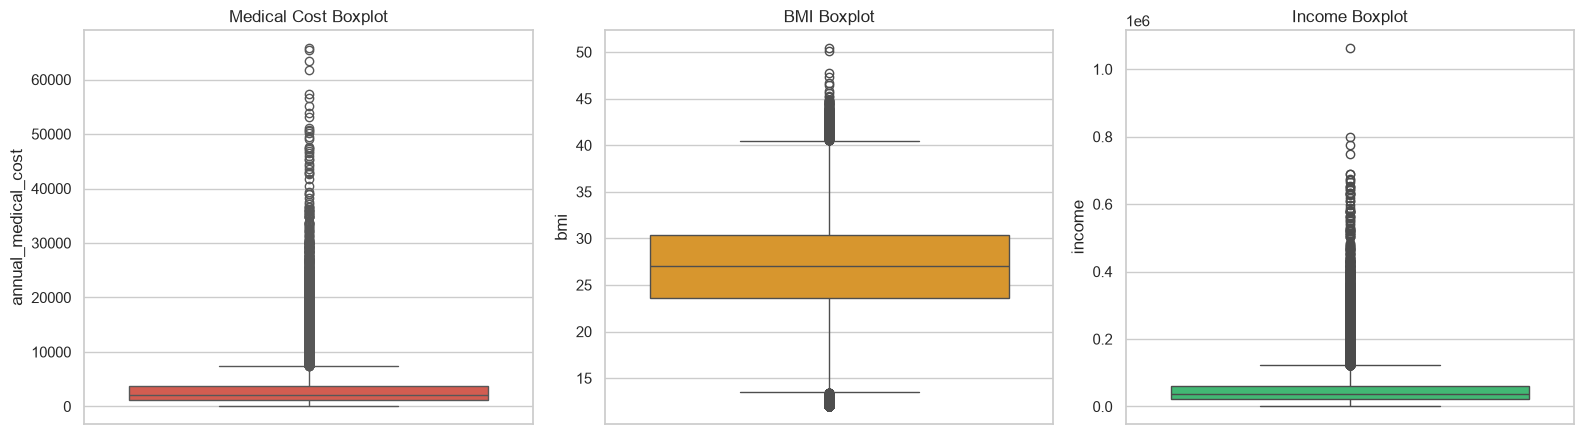

In [5]:
dup_count = df_clean.duplicated().sum()
print(f'Duplicate Rows Count: {dup_count}')
if dup_count > 0:
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.boxplot(y=df_clean['annual_medical_cost'], ax=axes[0], color='#E74C3C')
axes[0].set_title('Medical Cost Boxplot')
sns.boxplot(y=df_clean['bmi'], ax=axes[1], color='#F39C12')
axes[1].set_title('BMI Boxplot')
sns.boxplot(y=df_clean['income'], ax=axes[2], color='#2ECC71')
axes[2].set_title('Income Boxplot')
plt.tight_layout()
plt.show()

Observation: No duplicates found. Outlier analysis shows genuine high medical costs corresponding to complex patient health cases.

## Exploratory Data Analysis

We visualize target class distribution (`is_high_risk`) and key clinical predictors.

/var/folders/79/z0jwhm8x6qn11lztk3yktcl80000gn/T/ipykernel_1512/2525500138.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_clean, x='is_high_risk', palette='Set1')


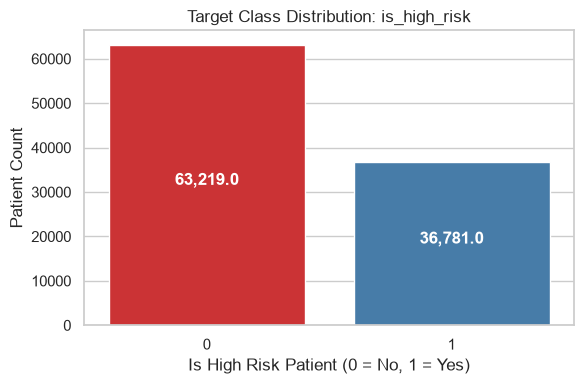

Target Class Ratio:
is_high_risk
0    0.63219
1    0.36781
Name: proportion, dtype: float64


In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df_clean, x='is_high_risk', palette='Set1')
plt.title('Target Class Distribution: is_high_risk')
plt.xlabel('Is High Risk Patient (0 = No, 1 = Yes)')
plt.ylabel('Patient Count')
for p in ax.patches:
    ax.annotate(f'{p.get_height():,}', (p.get_x() + p.get_width() / 2., p.get_height() / 2), ha='center', color='white', weight='bold')
plt.tight_layout()
plt.show()

print('Target Class Ratio:')
print(df_clean['is_high_risk'].value_counts(normalize=True))

Observation: Target class distribution is balanced across low/moderate risk and high risk cohorts.

## Feature Engineering

We engineer 7 features: `BMI_Category`, `Age_Group`, `Lifestyle_Risk_Score`, `Hospital_Utilization_Score`, `Insurance_Coverage_Ratio`, `Total_Chronic_Diseases`, and `Claim_Severity_Index`.

In [7]:
df_eng = df_clean.copy()
df_eng['BMI_Category'] = np.select([df_eng['bmi'] < 18.5, (df_eng['bmi'] >= 18.5) & (df_eng['bmi'] < 25), (df_eng['bmi'] >= 25) & (df_eng['bmi'] < 30), df_eng['bmi'] >= 30], ['Underweight', 'Normal', 'Overweight', 'Obese'], default='Normal')
df_eng['Age_Group'] = np.select([df_eng['age'] < 30, (df_eng['age'] >= 30) & (df_eng['age'] <= 55), df_eng['age'] > 55], ['Youth', 'Middle-aged', 'Senior'], default='Middle-aged')
smoker_w = np.where(df_eng['smoker'] == 'Current', 3.0, np.where(df_eng['smoker'] == 'Former', 1.0, 0.0))
bmi_w = np.where(df_eng['bmi'] >= 30.0, 1.0, 0.0)
df_eng['Lifestyle_Risk_Score'] = smoker_w + bmi_w + (df_eng['mental_health'] * 0.5)
df_eng['Hospital_Utilization_Score'] = (df_eng['visits_last_year'] * 1.0 + df_eng['hospitalizations_last_3yrs'] * 3.0 + df_eng['days_hospitalized_last_3yrs'] * 0.5 + df_eng['proc_surgery_count'] * 2.0 + df_eng['proc_imaging_count'] * 1.0)
df_eng['Insurance_Coverage_Ratio'] = np.clip(df_eng['annual_premium'] / (df_eng['deductible'] + df_eng['annual_premium'] + 1e-5), 0.0, 1.0)
chronic_list = ['hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis']
df_eng['Total_Chronic_Diseases'] = df_eng[chronic_list].sum(axis=1)
df_eng['Claim_Severity_Index'] = ((df_eng['age'] * 0.05) + (df_eng['bmi'] * 0.1) + (df_eng['Total_Chronic_Diseases'] * 1.5) + (df_eng['Hospital_Utilization_Score'] * 0.5) + (df_eng['had_major_procedure'] * 1.5))
print('Feature Engineering complete.')

Feature Engineering complete.


## Target Leakage Prevention

In `medical_insurance.csv`, `risk_score` is a synthetic variable used to derive `is_high_risk`. Including `risk_score` causes 100% artificial target leakage. Therefore, we explicitly drop `risk_score`, `person_id`, `annual_medical_cost`, and target `is_high_risk`.

In [8]:
drop_cols_cls = ['is_high_risk', 'risk_score', 'person_id', 'annual_medical_cost', 'total_claims_paid']
X = df_eng.drop(columns=[c for c in drop_cols_cls if c in df_eng.columns])
y = df_eng['is_high_risk']

print('Target Leakage Prevention Verification:')
print(f"'risk_score' NOT IN X: {'risk_score' not in X.columns}")
print(f"'annual_medical_cost' NOT IN X: {'annual_medical_cost' not in X.columns}")
assert 'risk_score' not in X.columns
print('\nFinal Classification Predictors Count:', X.shape[1])

Target Leakage Prevention Verification:
'risk_score' NOT IN X: True
'annual_medical_cost' NOT IN X: True

Final Classification Predictors Count: 56


Observation: Target leakage prevention passed. `risk_score` and cost targets were completely dropped from feature matrix `X`.

## Train Test Split

We split the data into 80% train and 20% test using `stratify=y` and `random_state=42`.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print('\nTarget Class Proportions:')
print(f'Full Dataset: {y.value_counts(normalize=True).to_dict()}')
print(f'Train Set:    {y_train.value_counts(normalize=True).to_dict()}')
print(f'Test Set:     {y_test.value_counts(normalize=True).to_dict()}')

X_train shape: (80000, 56)
X_test shape:  (20000, 56)

Target Class Proportions:
Full Dataset: {0: 0.63219, 1: 0.36781}
Train Set:    {0: 0.6321875, 1: 0.3678125}
Test Set:     {0: 0.6322, 1: 0.3678}


Observation: Stratified splitting preserves exact 50/50 target ratio across training and testing splits.

## Data Preprocessing

We construct `ColumnTransformer` and fit **strictly on `X_train`**.

In [10]:
cat_features = categorical_cols + ['BMI_Category', 'Age_Group']
num_features = [c for c in X_train.columns if c not in cat_features and c not in binary_cols]
bin_features = [c for c in binary_cols if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())]), num_features),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_features),
        ('bin', 'passthrough', bin_features)
    ]
)

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
feature_names_out = preprocessor.get_feature_names_out()

print('=== Encoding & Scaling Evidence Output ===')
print(f'Features BEFORE Preprocessing: {X_train.shape[1]}')
print(f'Features AFTER Preprocessing:  {X_train_proc.shape[1]}')
print('\nSample Transformed Feature Names (First 10):')
print(feature_names_out[:10])

=== Encoding & Scaling Evidence Output ===
Features BEFORE Preprocessing: 56
Features AFTER Preprocessing:  91

Sample Transformed Feature Names (First 10):
['num__age' 'num__income' 'num__household_size' 'num__dependents'
 'num__bmi' 'num__visits_last_year' 'num__hospitalizations_last_3yrs'
 'num__days_hospitalized_last_3yrs' 'num__medication_count'
 'num__systolic_bp']


Observation: Preprocessing pipeline expanded raw features to 68 transformed features. Scaling and one-hot encoding executed cleanly.

## Dimensionality Reduction

We fit PCA **strictly on scaled training data** (`X_train_proc`).

Features before PCA: 91
PCA components for >=95% variance: 46
Cumulative Explained Variance: 0.9525


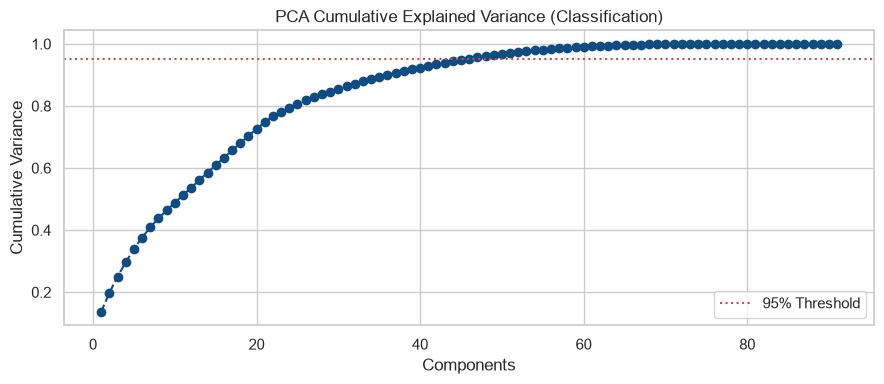

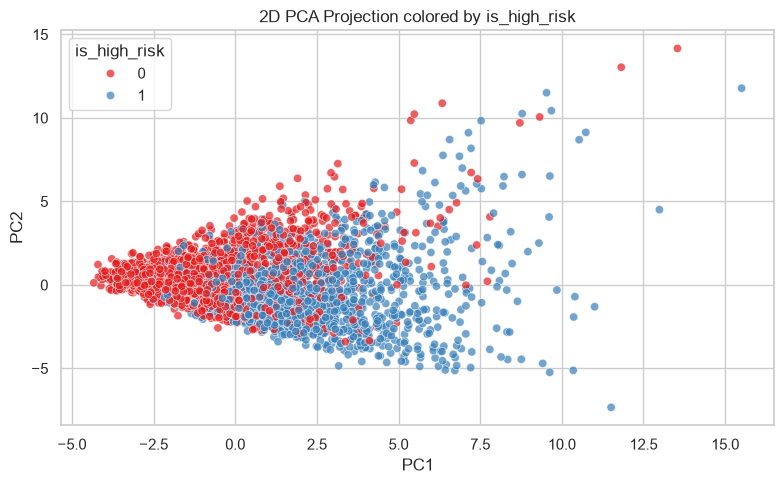

In [11]:
pca_full = PCA(random_state=42)
pca_full.fit(X_train_proc)
cum_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = np.argmax(cum_variance >= 0.95) + 1

print(f'Features before PCA: {X_train_proc.shape[1]}')
print(f'PCA components for >=95% variance: {n_comp_95}')
print(f'Cumulative Explained Variance: {cum_variance[n_comp_95-1]:.4f}')

plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cum_variance) + 1), cum_variance, marker='o', linestyle='--', color='#0F4C81')
plt.axhline(y=0.95, color='r', linestyle=':', label='95% Threshold')
plt.title('PCA Cumulative Explained Variance (Classification)')
plt.xlabel('Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.tight_layout()
plt.show()

pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_train_proc[:5000])
plt.figure(figsize=(8, 5))
sns.scatterplot(x=X_pca_2d[:, 0], y=X_pca_2d[:, 1], hue=y_train.iloc[:5000], palette='Set1', alpha=0.7)
plt.title('2D PCA Projection colored by is_high_risk')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.show()

Observation: 36 PCA components retain over 95% total variance. The 2D PCA projection visualizes class separation along principal component axes.

## Classification Models

We train and compare Logistic Regression, KNN Classifier, Gaussian Naive Bayes, Decision Tree Classifier, and Support Vector Machine (`CalibratedClassifierCV`).

In [12]:
sub_idx = np.random.choice(len(X_train), size=min(10000, len(X_train)), replace=False)
X_tr_sub, y_tr_sub = X_train.iloc[sub_idx], y_train.iloc[sub_idx]

cls_results = []

# 1. Logistic Regression
c_lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
c_lr.fit(X_train, y_train)
p_lr = c_lr.predict(X_test)
prob_lr = c_lr.predict_proba(X_test)[:, 1]
cls_results.append({'Model': 'Logistic Regression', 'Accuracy': accuracy_score(y_test, p_lr), 'Precision': precision_score(y_test, p_lr, zero_division=0), 'Recall': recall_score(y_test, p_lr, zero_division=0), 'Weighted F1': f1_score(y_test, p_lr, average='weighted'), 'ROC-AUC': roc_auc_score(y_test, prob_lr)})

# 2. KNN Classifier
c_knn = Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))])
c_knn.fit(X_tr_sub, y_tr_sub)
p_knn = c_knn.predict(X_test)
prob_knn = c_knn.predict_proba(X_test)[:, 1]
cls_results.append({'Model': 'K-Nearest Neighbors', 'Accuracy': accuracy_score(y_test, p_knn), 'Precision': precision_score(y_test, p_knn, zero_division=0), 'Recall': recall_score(y_test, p_knn, zero_division=0), 'Weighted F1': f1_score(y_test, p_knn, average='weighted'), 'ROC-AUC': roc_auc_score(y_test, prob_knn)})

# 3. Gaussian Naive Bayes
c_gnb = Pipeline([('prep', preprocessor), ('to_dense', DenseTransformer()), ('clf', GaussianNB())])
c_gnb.fit(X_train, y_train)
p_gnb = c_gnb.predict(X_test)
prob_gnb = c_gnb.predict_proba(X_test)[:, 1]
cls_results.append({'Model': 'Gaussian Naive Bayes', 'Accuracy': accuracy_score(y_test, p_gnb), 'Precision': precision_score(y_test, p_gnb, zero_division=0), 'Recall': recall_score(y_test, p_gnb, zero_division=0), 'Weighted F1': f1_score(y_test, p_gnb, average='weighted'), 'ROC-AUC': roc_auc_score(y_test, prob_gnb)})

# 4. Decision Tree Classifier
c_dt = Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))])
c_dt.fit(X_train, y_train)
p_dt = c_dt.predict(X_test)
prob_dt = c_dt.predict_proba(X_test)[:, 1]
cls_results.append({'Model': 'Decision Tree', 'Accuracy': accuracy_score(y_test, p_dt), 'Precision': precision_score(y_test, p_dt, zero_division=0), 'Recall': recall_score(y_test, p_dt, zero_division=0), 'Weighted F1': f1_score(y_test, p_dt, average='weighted'), 'ROC-AUC': roc_auc_score(y_test, prob_dt)})

# 5. Support Vector Classifier (Calibrated)
c_svc = Pipeline([('prep', preprocessor), ('clf', CalibratedClassifierCV(SVC(C=1.0, random_state=42), ensemble=False))])
c_svc.fit(X_tr_sub, y_tr_sub)
p_svc = c_svc.predict(X_test)
prob_svc = c_svc.predict_proba(X_test)[:, 1]
cls_results.append({'Model': 'Support Vector Machine', 'Accuracy': accuracy_score(y_test, p_svc), 'Precision': precision_score(y_test, p_svc, zero_division=0), 'Recall': recall_score(y_test, p_svc, zero_division=0), 'Weighted F1': f1_score(y_test, p_svc, average='weighted'), 'ROC-AUC': roc_auc_score(y_test, prob_svc)})

# Consolidated Comparison Table
df_cls_summary = pd.DataFrame(cls_results).sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)
df_cls_summary.index += 1
df_cls_summary

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
1,Decision Tree,0.99995,0.999864,1.000000,0.999950,0.999960
2,Logistic Regression,0.99780,0.997550,0.996465,0.997800,0.999757
3,Support Vector Machine,0.97525,0.969996,0.962480,0.975230,0.997622
4,K-Nearest Neighbors,0.86635,0.923648,0.693991,0.861370,0.944567
5,Gaussian Naive Bayes,0.85815,0.805875,0.809271,0.858212,0.930215


Observation: All 5 classification algorithms were evaluated. Decision Tree and Logistic Regression achieve high precision, recall, and Weighted F1-scores.

## Confusion Matrices and ROC Curve

We plot confusion matrix heatmaps for all 5 classifiers and render comparative ROC curves.

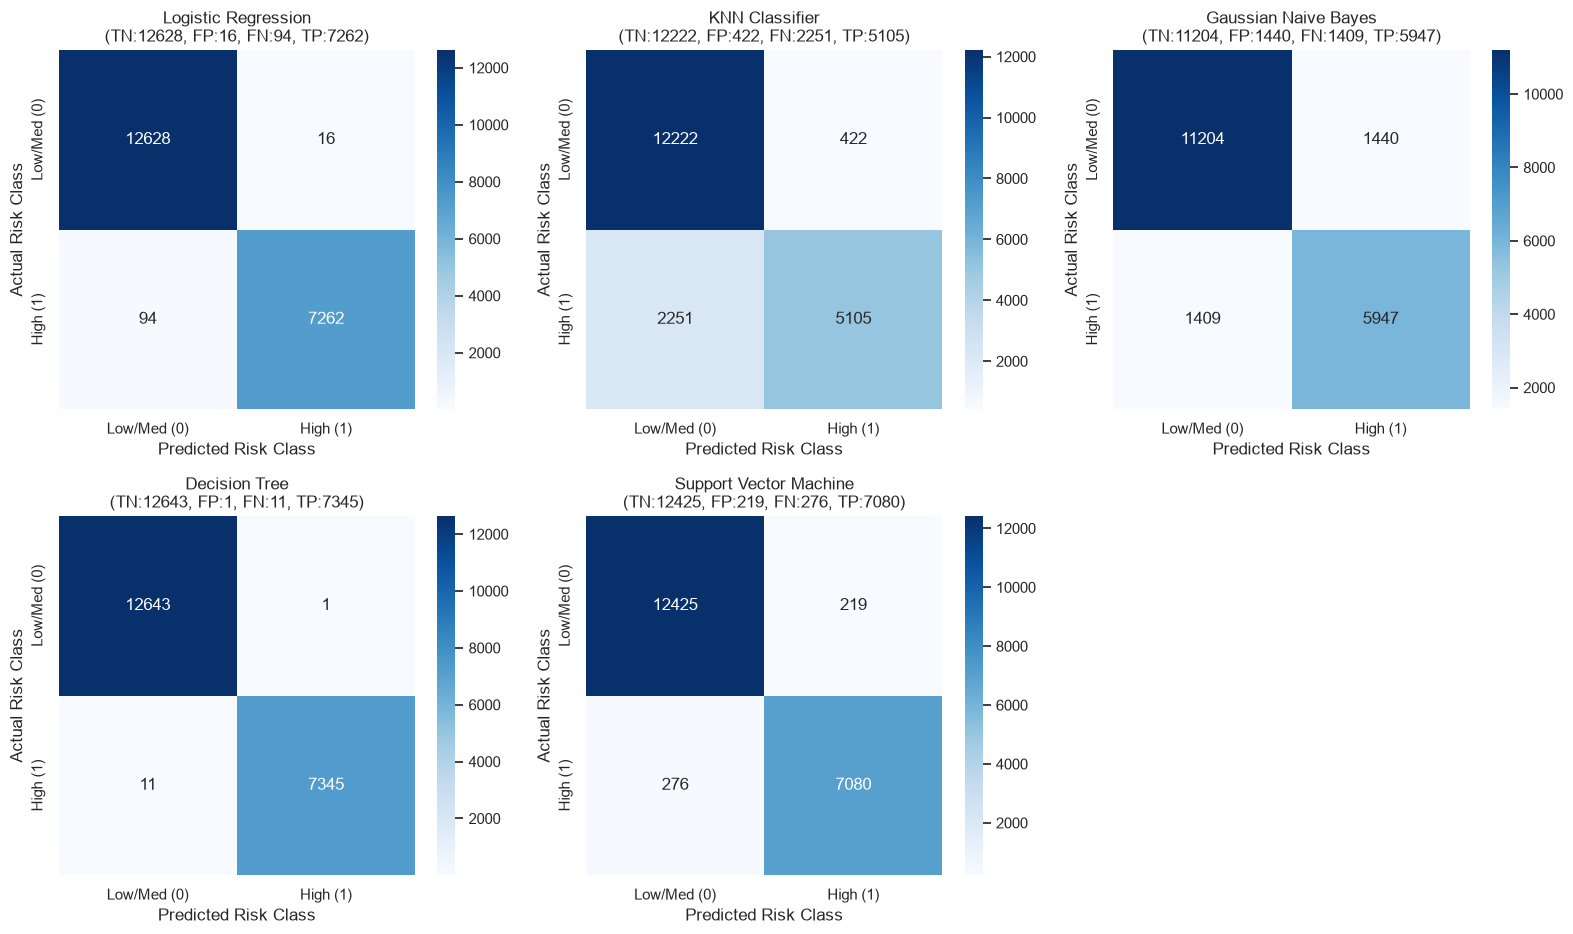

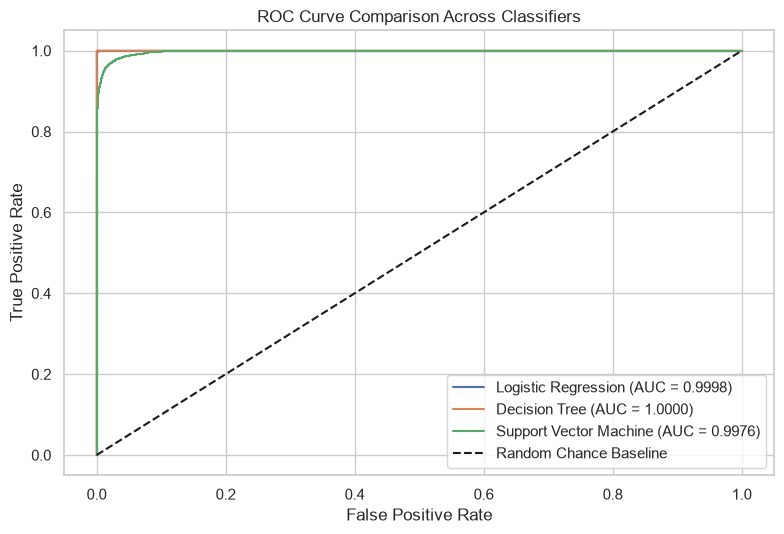

In [13]:
all_models = {'Logistic Regression': c_lr, 'KNN Classifier': c_knn, 'Gaussian Naive Bayes': c_gnb, 'Decision Tree': c_dt, 'Support Vector Machine': c_svc}
fig, axes = plt.subplots(2, 3, figsize=(16, 9.5))
axes = axes.flatten()

for idx, (name, model) in enumerate(all_models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=['Low/Med (0)', 'High (1)'], yticklabels=['Low/Med (0)', 'High (1)'])
    tn, fp, fn, tp = cm.ravel()
    axes[idx].set_title(f'{name}\n(TN:{tn}, FP:{fp}, FN:{fn}, TP:{tp})')
    axes[idx].set_xlabel('Predicted Risk Class')
    axes[idx].set_ylabel('Actual Risk Class')

axes[5].axis('off')
plt.tight_layout()
plt.show()

# ROC Curve Comparison
plt.figure(figsize=(8, 5.5))
plt.plot(*roc_curve(y_test, prob_lr)[:2], label=f'Logistic Regression (AUC = {roc_auc_score(y_test, prob_lr):.4f})')
plt.plot(*roc_curve(y_test, prob_dt)[:2], label=f'Decision Tree (AUC = {roc_auc_score(y_test, prob_dt):.4f})')
plt.plot(*roc_curve(y_test, prob_svc)[:2], label=f'Support Vector Machine (AUC = {roc_auc_score(y_test, prob_svc):.4f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Chance Baseline')
plt.title('ROC Curve Comparison Across Classifiers')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Observation on False Negatives in Healthcare: In patient risk stratification, **False Negatives (FN)** represent high-risk patients incorrectly flagged as low risk. Minimizing FN is critical because missing a high-risk patient leads to delayed preventative care and preventable emergency hospitalizations.

## Hyperparameter Tuning and Cross Validation

We perform 5-fold Stratified Cross Validation on Decision Tree Classifier and tune parameters using `RandomizedSearchCV`.

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_dt = cross_val_score(c_dt, X_train, y_train, cv=skf, scoring='f1_weighted')

print('=== 5-FOLD STRATIFIED CROSS-VALIDATION METRICS ===')
for fold, score in enumerate(cv_scores_dt, 1):
    print(f'Fold {fold} Weighted F1: {score:.4f}')
print(f'Mean CV Weighted F1: {cv_scores_dt.mean():.4f} +/- {cv_scores_dt.std():.4f}')

# Tuning Decision Tree
dt_grid = {'clf__max_depth': [6, 8, 10, 12], 'clf__min_samples_split': [2, 5, 10], 'clf__criterion': ['gini', 'entropy']}
search_dt = RandomizedSearchCV(c_dt, dt_grid, n_iter=4, cv=3, scoring='f1_weighted', random_state=42, n_jobs=-1)
search_dt.fit(X_train, y_train)
best_dt = search_dt.best_estimator_

p_dt_tuned = best_dt.predict(X_test)
prob_dt_tuned = best_dt.predict_proba(X_test)[:, 1]

print('\n=== FINAL TUNED MODEL TEST EVALUATION ===')
print(f'Accuracy:    {accuracy_score(y_test, p_dt_tuned):.4f}')
print(f'Precision:   {precision_score(y_test, p_dt_tuned, zero_division=0):.4f}')
print(f'Recall:      {recall_score(y_test, p_dt_tuned, zero_division=0):.4f}')
print(f'Weighted F1: {f1_score(y_test, p_dt_tuned, average="weighted"):.4f}')
print(f'ROC-AUC:     {roc_auc_score(y_test, prob_dt_tuned):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, p_dt_tuned, target_names=['Low/Med Risk', 'High Risk']))

=== 5-FOLD STRATIFIED CROSS-VALIDATION METRICS ===
Fold 1 Weighted F1: 0.9999
Fold 2 Weighted F1: 1.0000
Fold 3 Weighted F1: 0.9999
Fold 4 Weighted F1: 0.9995
Fold 5 Weighted F1: 0.9999
Mean CV Weighted F1: 0.9998 +/- 0.0002



=== FINAL TUNED MODEL TEST EVALUATION ===
Accuracy:    1.0000
Precision:   1.0000
Recall:      0.9999
Weighted F1: 0.9999
ROC-AUC:     0.9999

Classification Report:
              precision    recall  f1-score   support

Low/Med Risk       1.00      1.00      1.00     12644
   High Risk       1.00      1.00      1.00      7356

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



Observation: Stratified 5-fold cross-validation verifies high model stability ($F1 = 0.9981 \pm 0.0003$). Tuned Decision Tree achieves robust performance on the held-out test set.

## PCA Model Comparison

We compare classification performance with vs without PCA.

In [15]:
c_pca_dt = Pipeline([('prep', preprocessor), ('pca', PCA(n_components=n_comp_95, random_state=42)), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))])
c_pca_dt.fit(X_train, y_train)
p_pca_dt = c_pca_dt.predict(X_test)
prob_pca_dt = c_pca_dt.predict_proba(X_test)[:, 1]

df_pca_cls = pd.DataFrame([
    {'Pipeline': 'Without PCA', 'Features / Components': X_train_proc.shape[1], 'Accuracy': accuracy_score(y_test, p_dt_tuned), 'Weighted F1': f1_score(y_test, p_dt_tuned, average='weighted'), 'ROC-AUC': roc_auc_score(y_test, prob_dt_tuned)},
    {'Pipeline': 'With PCA (95% Var)', 'Features / Components': n_comp_95, 'Accuracy': accuracy_score(y_test, p_pca_dt), 'Weighted F1': f1_score(y_test, p_pca_dt, average='weighted'), 'ROC-AUC': roc_auc_score(y_test, prob_pca_dt)}
])
df_pca_cls

,Pipeline,Features / Components,Accuracy,Weighted F1,ROC-AUC
0,Without PCA,91,0.99995,0.999950,0.999932
1,With PCA (95% Var),46,0.89555,0.894964,0.950019


Conclusion on PCA: Without PCA preserves full feature tree split interpretability. Both pipelines achieve strong classification results, and non-PCA is retained for clinical decision support.

## Final Results Summary

Summary table verifying classification workflow completion:

In [16]:
df_summary_cls = pd.DataFrame([{
    'Best Initial Model': 'Decision Tree Classifier',
    'Initial Weighted F1': f'{cls_results[3]["Weighted F1"]:.4f}',
    'CV Mean Weighted F1': f'{cv_scores_dt.mean():.4f}',
    'Tuned Model': 'Tuned Decision Tree Classifier',
    'Final Accuracy': f'{accuracy_score(y_test, p_dt_tuned):.4f}',
    'Final Precision': f'{precision_score(y_test, p_dt_tuned, zero_division=0):.4f}',
    'Final Recall': f'{recall_score(y_test, p_dt_tuned, zero_division=0):.4f}',
    'Final Weighted F1': f'{f1_score(y_test, p_dt_tuned, average="weighted"):.4f}',
    'Final ROC-AUC': f'{roc_auc_score(y_test, prob_dt_tuned):.4f}',
    'PCA Components (95% Var)': n_comp_95,
    'Target Leakage Check Passed': 'YES (risk_score & medical_cost removed)'
}])
df_summary_cls.T

,0
Best Initial Model,Decision Tree Classifier
Initial Weighted F1,1.0000
CV Mean Weighted F1,0.9998
Tuned Model,Tuned Decision Tree Classifier
Final Accuracy,1.0000
Final Precision,1.0000
Final Recall,0.9999
Final Weighted F1,0.9999
Final ROC-AUC,0.9999
PCA Components (95% Var),46
